In [60]:
import numpy as np

from sklearn.preprocessing import MinMaxScaler
import pandas as pd
from scipy.sparse import csr_matrix, csgraph
from sklearn.neighbors import kneighbors_graph
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import euclidean_distances

import pandas as pd
from sklearn.metrics import accuracy_score, f1_score

import igraph as ig
from Bio import Phylo

from matplotlib import pyplot as plt

import time



from sklearn.manifold import TSNE

# from sklearn.decomposition import PCA


from scipy.linalg import inv

In [61]:
def LLGC(X, Y, y, media, amostras, alfa):
    # Calcular a variância
    varianca = np.sum((X - media)**2) / amostras

    # Calcular a matriz de afinidade W
    dist_sq = np.sum((X[:, np.newaxis, :] - X[np.newaxis, :, :])**2, axis=2)
    W = np.exp(-dist_sq / (2 * varianca))
    np.fill_diagonal(W, 0)

    # Calcular a matriz diagonal D
    D = np.diag(W.sum(axis=1))
    D_inv_sqrt = np.linalg.inv(np.sqrt(D))
    S = D_inv_sqrt @ W @ D_inv_sqrt
    
    # calcular a matriz identidade
    I = np.eye(X.shape[0])
    
    # Calcular a matriz de saída
    F = (1 - alfa) * np.linalg.inv(I - alfa * S).dot(Y)

    # Determinar a classe prevista para cada amostra
    result = np.argmax(F, axis=1)
    # acertos = np.sum(result == y)
    
    # # Calculando as métricas
    # accuracy = accuracy_score(y, result)
    # f1 = f1_score(y, result, average='macro')
    # jaccard = jaccard_score(y, result, average='macro')

    # print(f'% de erros {1 - accuracy} e taxa de acerto: {accuracy}')
    return F, result


In [62]:
def geodesic_knn_graph(X, n_neighbors=10):
    # Construir grafo k-NN com distâncias euclidianas
    knn_graph = kneighbors_graph(X, n_neighbors=n_neighbors, mode='distance', include_self=True)
    
    # Calcular a matriz de distância geodésica utilizando o algoritmo de Floyd-Warshall
    geodesic_dist_matrix = csgraph.shortest_path(knn_graph, method='auto', directed=False)
    
    # Construir novo grafo k-NN com base nas distâncias geodésicas
    n_samples = X.shape[0]
    geodesic_knn = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
        sorted_neighbors = np.argsort(geodesic_dist_matrix[i])[:n_neighbors]
        for j in sorted_neighbors:
            geodesic_knn[i, j] = geodesic_dist_matrix[i, j]
            geodesic_knn[j, i] = geodesic_dist_matrix[i, j]  # Grafo não direcionado
    
    # Convertendo para matriz esparsa
    geodesic_knn_sparse = csr_matrix(geodesic_knn)
    
    return geodesic_knn_sparse, geodesic_knn, geodesic_dist_matrix


In [63]:
def map_classes(y):
    # realiza o mapeamento das classes e suas posicoes no vetor. necessario pois ha datasets que nao tem todas as classes de forma sequencial
    # ex. set(y) = [1,2,3,6,8] ao inves de [0,1,2,3,4] 
    class_map = {}
    for id,clas in enumerate(np.unique(y)):
        print(clas)
        class_map[id] = clas
    # Invertendo o dicionário para mapeamento de valores para chaves
    inverse_dic = {v: k for k, v in class_map.items()}
    
    # Substituindo os valores no vetor pelas chaves do dicionário
    # assim o vetor y tera classes de 0 a n, o que nao ocorre em todas os datasets
    y = np.array([inverse_dic[val] for val in y])
    
    return y

# Dados

In [64]:
# In[heart]
from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features

rows_without_nan = ~X.isna().any(axis=1)
X = X.dropna().to_numpy()
y = heart_disease.data.targets.to_numpy().flatten()[rows_without_nan]

base = 'heart'

index = np.random.permutation(len(X))
X = X[index]
y = y[index]
y = map_classes(y)

# # Remove elements of class 4, pois em poucas amostras, o que acarreta em erros qnd tem muitos vizinhos para a geodesica
for cls in [4]:
    mask = y != cls
    X = X[mask]
    y = y[mask]


transformer = MinMaxScaler().fit(X)
X = transformer.transform(X)

n_amostras = len(X)

# pca = PCA(n_components=2)
# pca.fit(X)
# 
# X = pca.fit_transform(X)


heart = (X,y)


0
1
2
3
4


0
1
2
3
4


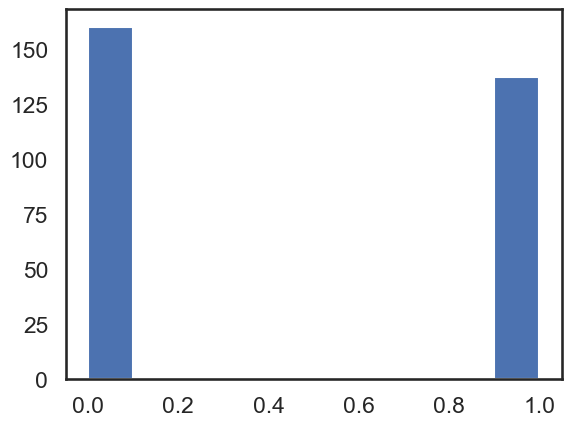

In [65]:
from ucimlrepo import fetch_ucirepo
import numpy as np

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features

rows_without_nan = ~X.isna().any(axis=1)
X = X.dropna().to_numpy()
y = heart_disease.data.targets.to_numpy().flatten()[rows_without_nan]

base = 'heart'

index = np.random.permutation(len(X))
X = X[index]
y = y[index]
y = map_classes(y)

# Alterar as classes 1, 2, 3 e 4 para 1
y = np.where((y >= 1) & (y <= 4), 1, y)

transformer = MinMaxScaler().fit(X)
X = transformer.transform(X)

n_amostras = len(X)

# pca = PCA(n_components=2)
# pca.fit(X)
# 
# X = pca.fit_transform(X)


heart_2classes = (X,y)
plt.hist(y)
plt.show()

In [66]:
from sklearn.preprocessing import LabelEncoder
# In[sonar]:

from ucimlrepo import fetch_ucirepo

# fetch dataset
connectionist_bench_sonar_mines_vs_rocks = fetch_ucirepo(id=151)

# data (as pandas dataframes)
X = connectionist_bench_sonar_mines_vs_rocks.data.features.to_numpy()
y = connectionist_bench_sonar_mines_vs_rocks.data.targets.to_numpy().flatten()

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

base = 'sonar'
index = np.random.permutation(len(X))
X = X[index]
y = y[index]
y = map_classes(y)

transformer = MinMaxScaler().fit(X)
X = transformer.transform(X)

n_amostras = len(X)

# pca = PCA(n_components=2)
# pca.fit(X)
# 
# X = pca.fit_transform(X)


sonar = (X,y)


0
1


In [67]:
# In[musk_v1]
from ucimlrepo import fetch_ucirepo

# fetch dataset
musk_version_1 = fetch_ucirepo(id=74)
musk_version_1.data.features.drop('conformation_name', axis=1, inplace=True)
musk_version_1.data.features.drop('molecule_name', axis=1, inplace=True)

# data (as pandas dataframes)
X = musk_version_1.data.features.to_numpy()
y = musk_version_1.data.targets.to_numpy().flatten()


base = 'musk_v1'
index = np.random.permutation(len(X))
X = X[index]
y = y[index]
y = map_classes(y)

transformer = MinMaxScaler().fit(X)
X = transformer.transform(X)

n_amostras = len(X)

# pca = PCA(n_components=2)
# pca.fit(X)
# 
# X = pca.fit_transform(X)


musk = (X,y)


0.0
1.0


C:\Users\brenocaetano\AppData\Local\Temp\ipykernel_22480\2590120072.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  musk_version_1.data.features.drop('conformation_name', axis=1, inplace=True)
C:\Users\brenocaetano\AppData\Local\Temp\ipykernel_22480\2590120072.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  musk_version_1.data.features.drop('molecule_name', axis=1, inplace=True)


In [68]:
# ==========================================
# BASE TWOMOONS (Via arquivo externo)
# ==========================================
from dados_twomoons import X3, y3
import numpy as np
from sklearn.preprocessing import MinMaxScaler

X = X3
y = y3.flatten()

base = 'twomoons'

# Embaralhando
index = np.random.permutation(len(X))
X = X[index]
y = y[index]

# Mapeando classes (padrão do seu notebook)
y = map_classes(y)

# Escalonamento
transformer = MinMaxScaler().fit(X)
X = transformer.transform(X)

n_amostras = len(X)

# Criando a tupla
twomoons = (X, y)

0
1


In [69]:
# ==========================================
# BASE MNIST (100 amostras por classe)
# ==========================================
from sklearn.datasets import fetch_openml
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# fetch dataset (pode demorar alguns segundos na 1ª execução)
mnist_data = fetch_openml('mnist_784', version=1, cache=True, parser='auto')
X_mnist = mnist_data.data.to_numpy()
y_mnist = mnist_data.target.to_numpy().astype(int)

# Sorteando 500 amostras para cada classe
X_sampled = []
y_sampled = []

np.random.seed(42) # Mantém as amostras iguais em todas as execuções
for cls in range(10): # Classes de 0 a 9
    idx = np.where(y_mnist == cls)[0]
    idx_sampled = np.random.choice(idx, 100, replace=False)
    X_sampled.append(X_mnist[idx_sampled])
    y_sampled.append(y_mnist[idx_sampled])

X = np.vstack(X_sampled)
y = np.hstack(y_sampled)

base = 'mnist'

# Embaralhando as 1000 amostras
index = np.random.permutation(len(X))
X = X[index]
y = y[index]

# Mapeando classes
y = map_classes(y)

# Escalonamento
transformer = MinMaxScaler().fit(X)
X = transformer.transform(X)

n_amostras = len(X)

# Criando a tupla
mnist = (X, y)

0
1
2
3
4
5
6
7
8
9


In [70]:
datasets = [
    heart_2classes,
    musk,
    sonar,
    twomoons,
    mnist
]

datasets_name = [
    'heart_2classes',
    'musk',
    'sonar',
    'twomoons',
    'mnist'
]

In [71]:
# Função para converter a árvore em um grafo do igraph
def tree_to_igraph(tree):
    edges = []
    node_counter = 0
    clade_to_id = {}
    clade_names = {}
    weights = []
        

    for clade in tree.traverse("levelorder"):
    # for clade in tree.find_clades(order="level"):
        if clade not in clade_to_id:
            clade_name = clade.name if clade.name else f"node_{node_counter}"
            clade_to_id[clade] = node_counter
            clade_names[node_counter] = clade_name
            node_counter += 1
        for child in clade.children:
        # for child in clade.clades:
            if child not in clade_to_id:
                child_name = child.name if child.name else f"node_{node_counter}"
                clade_to_id[child] = node_counter
                clade_names[node_counter] = child_name
                node_counter += 1
            edges.append((clade_to_id[clade], clade_to_id[child]))
            # print(clade.branch_length, child.branch_length)
            # print(clade_to_id[clade], clade_to_id[child])
            # print(clade_names[clade_to_id[clade]], clade_names[clade_to_id[child]])
            # testar com clade.branch_length e com 1/child.branch_lenght
            # weights.append(clade.branch_length or 1.0)
            
            weights.append(1/child.dist if child.dist is not None and child.dist != 0.0 else 0.000001)
            
            # try:
            #     weights.append(child.branch_length)
            # except:
            #     weights.append(0.0)
    
    # print("Edges:", edges)  # Adiciona instrução de depuração
    # print("Clade Names:", clade_names)  # Adiciona instrução de depuração
    g = ig.Graph(edges=edges)
    g.vs["name"] = [clade_names[i] for i in range(len(clade_names))]
    g.vs["label"] = [clade_names[i] for i in range(len(clade_names))]
    g.es["weights"] = weights
    return g

In [72]:
def configurar_Y(amostras, y, qnt, num_classes):
    # Inicializar a matriz Y com zeros
    Y = np.zeros((amostras, num_classes))

    # Calcular a quantidade de amostras a serem rotuladas por classe
    qntAmostrasPorClasse = qnt
    # print(f'qnt por classe: {qntAmostrasPorClasse} amostras: {amostras} num_c: {num_classes} qnt: {qnt}' )

    # Criar um conjunto de índices disponíveis
    indices_disponiveis = set(range(amostras))

    for classe in range(num_classes):
        # Obter índices de todas as amostras da classe atual
        indices_classe = set(np.where(y == classe)[0])

        # Obter a interseção de índices disponíveis e índices da classe
        indices_classe_disponiveis = list(indices_classe & indices_disponiveis)
        
        # Selecionar aleatoriamente amostras a serem rotuladas para a classe atual
        indices_rotulados = np.random.choice(indices_classe_disponiveis, qntAmostrasPorClasse, replace=False)

        # Atribuir rótulos às amostras selecionadas
        Y[indices_rotulados, classe] = 1

        # Remover os índices selecionados do conjunto de disponíveis
        indices_disponiveis -= set(indices_rotulados)

    return Y

In [73]:
def experiment(X, y, grupos, qntAmostrasPorClasse = 1, num_exec = 30, alpha = 0.2):
    media=X.mean(axis=0)
    accuracy_own = []
    accuracy_llgc = []
    f1_own_macro = []
    f1_llgc_macro = []
    time_llgc = []
    time_phydl = []
    
    for i in range(num_exec):

        Y = configurar_Y(X.shape[0], y, qntAmostrasPorClasse, len(np.unique(y)))
        
        start_time_llgc = time.perf_counter()
        # usando minha implementacao
        F, y_predict_llgc = LLGC(X, Y, y, media, X.shape[0], alpha)
        end_time_llgc = time.perf_counter()
        # print((X.shape, Y.shape, y.shape, media.shape, X.shape[0], alpha))
        
        y_predict_own = np.copy(y_predict_llgc)
        # saida llgc antes de aplicar o argmax(y); shape(n_samples,n_class)
        # transduction = llgc.predict_proba(X)
        transduction = F
        start_time_phydl = time.perf_counter()
        for grupo in grupos:
            # obtenção da qnt de informação por grupo
            classe_do_grupo = np.argmax(np.sum(transduction[grupo], axis=0))
            # atribuicao do mesmo rotulo a todos os elementos do grupo
            y_predict_own[grupo] = classe_do_grupo
        
        end_time_phydl = time.perf_counter()
            
        # ==============================================================
        # Y.sum(axis=1) == 0 retorna True APENAS para os dados não rotulados
        # ==============================================================
        unlabeled_mask = Y.sum(axis=1) == 0

        # As métricas agora avaliam apenas o que o modelo não conhecia
        accuracy_own.append(accuracy_score(y[unlabeled_mask], y_predict_own[unlabeled_mask]))
        accuracy_llgc.append(accuracy_score(y[unlabeled_mask], y_predict_llgc[unlabeled_mask]))

        f1_own_macro.append(f1_score(y[unlabeled_mask], y_predict_own[unlabeled_mask], average='macro'))
        f1_llgc_macro.append(f1_score(y[unlabeled_mask], y_predict_llgc[unlabeled_mask], average='macro'))
        # ==============================================================

        time_llgc.append(end_time_llgc-start_time_llgc)
        time_phydl.append(end_time_phydl-start_time_phydl)
                    
    return accuracy_own, accuracy_llgc, f1_own_macro, f1_llgc_macro, time_llgc, time_phydl, y_predict_llgc, y_predict_own

In [74]:
def get_samples_per_class(y, max_percentage=0.2):
    """
    Calcula a quantidade de amostras por classe para um subconjunto balanceado,
    garantindo que o total de amostras seja um múltiplo do número de classes e menor ou igual
    a uma porcentagem máxima do total de amostras.

    Parâmetros:
    - y: array-like ou Series, vetor de rótulos.
    - max_percentage: proporção máxima de amostras a serem selecionadas (padrão: 20%).

    Retorna:
    - samples_per_class: quantidade de amostras por classe.
    """
    y = pd.Series(y) if not isinstance(y, pd.Series) else y
    
    unique_classes = y.unique()
    num_classes = len(unique_classes)
    total_samples = len(y)
    
    # Calcula o número máximo de amostras permitido
    max_samples = int(total_samples * max_percentage)
    
    # Encontra o maior múltiplo do número de classes que é menor ou igual a max_samples
    total_samples_selected = (max_samples // num_classes) * num_classes
    
    if total_samples_selected == 0:
        raise ValueError("O número de amostras disponíveis é insuficiente para a seleção desejada.")
    
    # Calcula o número de amostras por classe
    samples_per_class = total_samples_selected // num_classes
    
    return samples_per_class

# Exemplo de uso:
# samples_per_class = get_samples_per_class(y)
# print(f"Quantidade de amostras por classe: {samples_per_class}")


In [75]:
from Bio.Phylo.TreeConstruction import DistanceTreeConstructor, _DistanceMatrix
from Bio import Phylo
from tqdm import tqdm

In [76]:
def damicore(X, y, tipo_distancia, n_neighbors, algo_deteccao, resolution = 1):
# preprocess dataset, split into training and test part
#     X, y = ds
    # print(X.shape, y.shape)
    
    # matriz de distancia
    if tipo_distancia == 'geodesica':
        # # Construir grafo k-NN com distância geodésica
        geodesic_knn_sparse, geodesic_knn, distancias = geodesic_knn_graph(X, n_neighbors=n_neighbors)
    elif tipo_distancia == 'euclidiana':
        # Calcule a distância euclidiana
        distancias = euclidean_distances(X, X)
    # Filograma
    
    
    names = [str(i) for i in range(X.shape[0])]
    
    matriz = distancias
    
    # Extrair a triangular inferior e a diagonal
    matrix = []
    for i in range(matriz.shape[0]):
        linha = []
        for j in range(i + 1):
            linha.append(matriz[i, j])
        matrix.append(linha)
    # Crie uma matriz de distância no formato aceito pelo Biopython
    dm = _DistanceMatrix(names, matrix)
    # print(dm)
    
    # Construa a árvore usando o algoritmo Neighbor Joining
    constructor = DistanceTreeConstructor()
    tree = constructor.nj(dm)
    
    # # Exiba a árvore
    # Phylo.draw(tree)
    
    # Salve a árvore no formato Newick
    Phylo.write(tree, "nj_tree.newick", "newick")
    
    from ete3 import Tree, TreeStyle
    
    # Ler o arquivo Newick
    tree = Tree("nj_tree.newick", format=1)
    
    # Configurar o estilo da árvore (opcional)
    ts = TreeStyle()
    ts.show_leaf_name = True  # Mostrar os nomes das folhas
    ts.show_branch_length = True  # Mostrar os comprimentos dos ramos
    ts.show_branch_support = True  # Mostrar os valores de suporte dos ramos
    
    # Plotar a árvore
    # tree.show(tree_style=ts)
    
    # Detecção de comunidades e Carregar a árvore Newick
    # tree = Phylo.read("nj_tree.newick", "newick")
    
    # Converter a árvore em um grafo do igraph
    g = tree_to_igraph(tree)
    
    # Aplicar o algoritmo de detecção de comunidades (Louvain, neste caso)
    # communities = g.community_multilevel(weights=weights)
    

    # Aplicar o algoritmo de detecção de comunidades (fastgreedy, louvain ou edgebetweenness)
    if algo_deteccao == 'louvain':
        communities = g.community_multilevel(weights=g.es['weights'], resolution=resolution)
    elif algo_deteccao == 'fastgreedy':
        communities = g.community_fastgreedy(weights=g.es['weights']).as_clustering()
    elif algo_deteccao == 'edgebetweenness':
        communities = g.community_edge_betweenness(weights=g.es['weights']).as_clustering()

    # if algo_deteccao == 'louvain':
    #     communities = g.community_multilevel(weights=g.es['weights'], resolution=resolution)
    # elif algo_deteccao == 'fastgreedy':
    #     communities = g.community_fastgreedy(weights=g.es['weights']).as_clustering()
    
    # Obter a associação de cada vértice
    membership = communities.membership
    
    # Mostrar os resultados
    # print("Comunidades detectadas:", communities)
    # print("Associação dos vértices:", membership)
    
    grupos = []
    for sub in communities.subgraphs():
        grupos.append([int(elem) for elem in sub.vs["name"] if not elem.startswith("Inner")])
    
    return grupos

In [77]:
import os
from sklearn.manifold import TSNE
import seaborn as sns
from matplotlib import pyplot as plt

def gerarTsne(X, y, y_llgc, y_own, dataset, algo):
    tsne = TSNE(n_components=2, random_state=42, perplexity=3)
    X_tsne = tsne.fit_transform(X)

    y_names = [f"y_{dataset}_{algo}",
               f"y_llgc_{dataset}_{algo}",
               f"y_own_{dataset}_{algo}"]
    ys = [y, y_llgc, y_own]

    # Garante que a pasta existe
    os.makedirs("image/tsne", exist_ok=True)

    for y_plot, y_name in zip(ys, y_names):
        plt.figure(figsize=(10, 8))
        sns.scatterplot(
            x=X_tsne[:, 0],
            y=X_tsne[:, 1],
            hue=y_plot,
            palette=sns.color_palette("Set1", len(np.unique(y_plot))),
            legend="full",
            s=150,
            alpha=0.5,
        )

        legend = plt.legend(title="Class")
        newlabels = [f"Class {label.get_text()}" for label in legend.get_texts()]
        for label, newlabel in zip(legend.get_texts(), newlabels):
            label.set_text(newlabel)

        plt.xlabel("t-SNE Dimension 1")
        plt.ylabel("t-SNE Dimension 2")

        plt.savefig(f"image/tsne_{y_name}.png", dpi=600)
        plt.savefig(f"image/tsne_{y_name}.pdf", dpi=600)

        plt.close()

In [20]:

gerarImagens = False
num_exec = 30
# percent = 0.9
# alpha = 0.2
# n_neighbors = 10
# algo_deteccao = 'louvain'
# tipo_distancia = 'geodesica'
tipo_distancia = 'euclidiana'
algo_deteccao = ['fastgreedy']
# algo_deteccao = ['edgebetweenness', 'fastgreedy']
# algo_deteccao = 'louvain'
import numpy as np
import random

np.random.seed(42)
random.seed(42)

for algo_deteccao in algo_deteccao:
    if algo_deteccao == 'louvain': 
        resolutions = [0.25,0.5,0.75,1]
    else:
        resolutions = [1]
    
    # qntAmostrasPorClasse = [2, 4]
    # qntAmostrasPorClasse = [1, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
    # percentagem_por_classe = [2,4,6,8,10,12,14,16,18,20] # essa variavel armazena a perc total a ser rotulada, contando totas as classes
    percentagem_por_classe = [2,4,6,8,10,12,14,16,18,20] # essa variavel armazena a perc total a ser rotulada, contando totas as classes
    
    results = pd.DataFrame(columns=['Accuracy', 'f1_score_macro', 'Method', 'Alpha', 'Samples_labeled', 'Dataset', 'Neighbors', 'Resolution', 'ADC'])    
    for ds_cnt, ds in enumerate(datasets):
        print(ds_cnt, datasets_name[ds_cnt])
        # preprocess dataset, split into training and test part
        X, y = ds
        # usar linha abaixo se for em percentagem
        qntAmostrasPorClasse  = [get_samples_per_class(y, percent/100) for percent in percentagem_por_classe]
        
        for n_neighbors in [6]:    
            for resolution in resolutions:
                start_time_damicore = time.perf_counter() 
                grupos = damicore(X, y, tipo_distancia, n_neighbors, algo_deteccao, resolution)
                end_time_damicore = time.perf_counter()
                
                for qnt_in_percent, qnt in enumerate(qntAmostrasPorClasse):
                    
                    for alpha in [0.9]:

                    # for alpha in [0.1, 0.3, 0.5, 0.7, 0.9]:
                        # Execução ---
                        
                        (accuracy_own, accuracy_llgc, f1_own_macro, f1_llgc_macro, time_llgc, time_phydl, y_llgc, y_own) = experiment(X, y, grupos, qnt, num_exec=num_exec, alpha=alpha)
                        
                        data = {
                        'Accuracy': accuracy_own,
                        'f1_score_macro': f1_own_macro,
                        'Method': num_exec*['PhyDL'],
                        'Alpha': num_exec*[alpha],
                        'Samples_labeled': num_exec*[percentagem_por_classe[qnt_in_percent]],
                        'Dataset': num_exec*[datasets_name[ds_cnt]],
                        'Neighbors': num_exec*[n_neighbors],
                        'Resolution': num_exec*[resolution],
                        'ADC': num_exec*[algo_deteccao],
                        'Time': [x + y for x, y in zip(time_phydl, num_exec*[end_time_damicore - start_time_damicore])],
                        'Qnt_Amostras': num_exec*[X.shape[0]],
                        'Qnt_parametros': num_exec*[X.shape[1]],
                        'Execucao': list(range(1, num_exec+1)),
                        }
                    
                        df = pd.DataFrame(data)
                        
                        results = pd.concat((results, df), axis=0, ignore_index=True)
                        
                        data = {
                        'Accuracy': accuracy_llgc,
                        'f1_score_macro': f1_llgc_macro,
                        'Method': num_exec*['LLGC'],
                        'Alpha': num_exec*[alpha],
                        'Samples_labeled': num_exec*[percentagem_por_classe[qnt_in_percent]],
                        'Dataset': num_exec*[datasets_name[ds_cnt]],
                        'Neighbors': num_exec*[n_neighbors],
                        'Resolution': num_exec*[resolution],
                        'ADC': num_exec*[algo_deteccao],
                        'Time': time_llgc,
                        'Qnt_Amostras': num_exec*[X.shape[0]],
                        'Qnt_parametros': num_exec*[X.shape[1]],
                        'Execucao': list(range(1, num_exec+1)),
                        }
                    
                        df = pd.DataFrame(data)
                        
                        results = pd.concat((results, df), axis=0, ignore_index=True)
                    
                        # linhas utilizadas para gerar graficos para o artigo
                        if gerarImagens == True:
                            config_algoritmo = f"{algo_deteccao}_alpha{alpha}_perc{percentagem_por_classe[qnt_in_percent]}"
                            gerarTsne(X, y, y_llgc, y_own, datasets_name[ds_cnt], config_algoritmo)
                            
    print(f'resultados_'+algo_deteccao+'_'+tipo_distancia + '_llgc.csv') 
    results.to_csv(f'resultados_'+algo_deteccao+'_'+tipo_distancia + '_llgc.csv', decimal=',', sep=';')
                        


0 heart_2classes


C:\Users\brenocaetano\AppData\Local\Temp\ipykernel_33644\2454286160.py:71: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  results = pd.concat((results, df), axis=0, ignore_index=True)


1 musk
2 sonar
3 twomoons
4 mnist
resultados_fastgreedy_euclidiana_llgc.csv


# Gráficos

In [21]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================================
# Configurações gerais
# =========================================================
sns.set_theme(style="whitegrid", context="talk")

arquivo_fastgreedy = "resultados_fastgreedy_euclidiana_llgc.csv"
arquivo_edgebetweenness = "resultados_edgebetweenness_euclidiana_llgc.csv"

pasta_saida = "image/comparacao"
os.makedirs(pasta_saida, exist_ok=True)

# =========================================================
# Leitura dos resultados
# =========================================================
df_fast = pd.read_csv(arquivo_fastgreedy, sep=";", decimal=",")
df_edge = pd.read_csv(arquivo_edgebetweenness, sep=";", decimal=",")

results = pd.concat([df_fast, df_edge], ignore_index=True)

# =========================================================
# Padronização dos nomes dos métodos
# =========================================================
results["Method"] = results["Method"].astype(str)
results["ADC"] = results["ADC"].astype(str)
results["Dataset"] = results["Dataset"].astype(str)

mask_phydl = results["Method"].eq("PhyDL")
results.loc[mask_phydl & results["ADC"].eq("fastgreedy"), "Method"] = "PhyDL - Fastgreedy"
results.loc[mask_phydl & results["ADC"].eq("edgebetweenness"), "Method"] = "PhyDL - Edge Betweenness"

# remove duplicatas de LLGC que aparecem uma vez em cada arquivo
cols_base = [
    "Accuracy", "f1_score_macro", "Method", "Alpha", "Samples_labeled",
    "Dataset", "Neighbors", "Resolution", "Time", "Qnt_Amostras", "Qnt_parametros"
]

results_llgc = results[results["Method"] == "LLGC"].drop_duplicates(subset=cols_base)
results_phydl = results[results["Method"] != "LLGC"]

results = pd.concat([results_llgc, results_phydl], ignore_index=True)

# garantir tipo numérico
results["Accuracy"] = pd.to_numeric(results["Accuracy"], errors="coerce")
results["Samples_labeled"] = pd.to_numeric(results["Samples_labeled"], errors="coerce")

# ordem dos métodos e bases
ordem_metodos = ["LLGC", "PhyDL - Fastgreedy", "PhyDL - Edge Betweenness"]
ordem_bases = sorted(results["Dataset"].unique())

# paleta consistente
palette = {
    "LLGC": "#4C72B0",
    "PhyDL - Fastgreedy": "#55A868",
    "PhyDL - Edge Betweenness": "#C44E52"
}

# =========================================================
# Geração dos gráficos por base
# =========================================================
for dataset in ordem_bases:
    df_base = results[results["Dataset"] == dataset].copy()

    if df_base.empty:
        continue

    # -----------------------------
    # 1) Gráfico de barras
    # média da acurácia por percentual e método
    # -----------------------------
    resumo = (
        df_base.groupby(["Samples_labeled", "Method"], as_index=False)["Accuracy"]
        .mean()
    )

    plt.figure(figsize=(12, 7))
    ax = sns.barplot(
        data=resumo,
        x="Samples_labeled",
        y="Accuracy",
        hue="Method",
        hue_order=ordem_metodos,
        palette=palette
    )

    ax.set_title(f"{dataset} - Accuracy média por percentual rotulado")
    ax.set_xlabel("Percentual de amostras inicialmente rotuladas")
    ax.set_ylabel("Accuracy média")
    ax.set_ylim(0, 1.05)
    ax.legend(title="Método", loc="best")

    plt.tight_layout()
    plt.savefig(f"{pasta_saida}/barplot_accuracy_{dataset}.png", dpi=600, bbox_inches="tight")
    plt.savefig(f"{pasta_saida}/barplot_accuracy_{dataset}.pdf", dpi=600, bbox_inches="tight")
    plt.close()

    # -----------------------------
    # 2) Boxplot
    # distribuição da acurácia por percentual e método
    # -----------------------------
    plt.figure(figsize=(12, 7))
    ax = sns.boxplot(
        data=df_base,
        x="Samples_labeled",
        y="Accuracy",
        hue="Method",
        hue_order=ordem_metodos,
        palette=palette
    )

    ax.set_title(f"{dataset} - Distribuição da accuracy por percentual rotulado")
    ax.set_xlabel("Percentual de amostras inicialmente rotuladas")
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1.05)
    ax.legend(title="Método", loc="best")

    plt.tight_layout()
    plt.savefig(f"{pasta_saida}/boxplot_accuracy_{dataset}.png", dpi=600, bbox_inches="tight")
    plt.savefig(f"{pasta_saida}/boxplot_accuracy_{dataset}.pdf", dpi=600, bbox_inches="tight")
    plt.close()

print("Gráficos gerados com sucesso em:", pasta_saida)

Gráficos gerados com sucesso em: image/comparacao


In [55]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# =========================================================
# Configurações gerais
# =========================================================
sns.set_theme(style="whitegrid", context="talk")

arquivo_fastgreedy = "resultados_fastgreedy_euclidiana_llgc.csv"
arquivo_edgebetweenness = "resultados_edgebetweenness_euclidiana_llgc.csv"

pasta_saida = "image/comparacao"
os.makedirs(pasta_saida, exist_ok=True)

# =========================================================
# Leitura dos resultados
# =========================================================
df_fast = pd.read_csv(arquivo_fastgreedy, sep=";", decimal=",")
df_edge = pd.read_csv(arquivo_edgebetweenness, sep=";", decimal=",")

results = pd.concat([df_fast, df_edge], ignore_index=True)

# =========================================================
# Padronização dos nomes dos métodos
# =========================================================
results["Method"] = results["Method"].astype(str)
results["ADC"] = results["ADC"].astype(str)
results["Dataset"] = results["Dataset"].astype(str)

mask_phydl = results["Method"].eq("PhyDL")
results.loc[mask_phydl & results["ADC"].eq("fastgreedy"), "Method"] = "PhyDL - Fastgreedy"
results.loc[mask_phydl & results["ADC"].eq("edgebetweenness"), "Method"] = "PhyDL - Edge Betweenness"

# remove duplicatas de LLGC que aparecem uma vez em cada arquivo
cols_base = [
    "Accuracy", "f1_score_macro", "Method", "Alpha", "Samples_labeled",
    "Dataset", "Neighbors", "Resolution", "Time", "Qnt_Amostras", "Qnt_parametros"
]

results_llgc = results[results["Method"] == "LLGC"].drop_duplicates(subset=cols_base)
results_phydl = results[results["Method"] != "LLGC"]

results = pd.concat([results_llgc, results_phydl], ignore_index=True)

# garantir tipo numérico
results["Accuracy"] = pd.to_numeric(results["Accuracy"], errors="coerce")
results["Samples_labeled"] = pd.to_numeric(results["Samples_labeled"], errors="coerce")

# ordem dos métodos e bases
ordem_metodos = ["LLGC", "PhyDL - Fastgreedy", "PhyDL - Edge Betweenness"]
ordem_bases = sorted(results["Dataset"].unique())

# =========================================================
# NOVA PALETA (Cores Animadas, sem ser Neon)
# =========================================================
palette = {
    "LLGC": "#8B5CF6",                     # Violeta / Roxo Moderno
    "PhyDL - Fastgreedy": "#F59E0B",       # Âmbar / Laranja Dourado
    "PhyDL - Edge Betweenness": "#14B8A6"  # Turquesa / Ciano Suave
}

# =========================================================
# Função customizada para formatar o eixo Y como %
# =========================================================
def format_as_percent(y, position):
    return f"{y * 100:g}"

# =========================================================
# Geração dos gráficos por base
# =========================================================
for dataset in ordem_bases:
    df_base = results[results["Dataset"] == dataset].copy()

    if df_base.empty:
        continue

    # -----------------------------
    # 1) Gráfico de barras
    # -----------------------------
    resumo = (
        df_base.groupby(["Samples_labeled", "Method"], as_index=False)["Accuracy"]
        .mean()
    )

    plt.figure(figsize=(12, 7))
    ax = sns.barplot(
        data=resumo,
        x="Samples_labeled",
        y="Accuracy",
        hue="Method",
        hue_order=ordem_metodos,
        palette=palette
    )

    ax.set_xlabel("% of Points")
    ax.set_ylabel("Accuracy (%)")

    ax.yaxis.set_major_formatter(FuncFormatter(format_as_percent))

    # Legenda embaixo, horizontal, centralizada
    ax.legend(title=None, bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=3)

    plt.tight_layout()
    plt.savefig(f"{pasta_saida}/barplot_accuracy_{dataset}.png", dpi=600, bbox_inches="tight")
    plt.savefig(f"{pasta_saida}/barplot_accuracy_{dataset}.pdf", dpi=600, bbox_inches="tight")
    plt.close()

    # -----------------------------
    # 2) Boxplot
    # -----------------------------
    plt.figure(figsize=(12, 7))
    ax = sns.boxplot(
        data=df_base,
        x="Samples_labeled",
        y="Accuracy",
        hue="Method",
        hue_order=ordem_metodos,
        palette=palette,
        showfliers=False,
    )

    ax.set_xlabel("% of Points")
    ax.set_ylabel("Accuracy (%)")

    ax.yaxis.set_major_formatter(FuncFormatter(format_as_percent))

    # Legenda embaixo, horizontal, centralizada
    ax.legend(title=None, bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=3)

    plt.tight_layout()
    plt.savefig(f"{pasta_saida}/boxplot_accuracy_{dataset}.png", dpi=600, bbox_inches="tight")
    plt.savefig(f"{pasta_saida}/boxplot_accuracy_{dataset}.pdf", dpi=600, bbox_inches="tight")
    plt.close()

    # -----------------------------
    # 3) Gráfico de Ganho (PhyDL vs LLGC)
    # -----------------------------
    if "Execucao" in df_base.columns:
        df_llgc_gain = df_base[df_base["Method"] == "LLGC"][["Samples_labeled", "Execucao", "Accuracy"]]
        df_phydl_gain = df_base[df_base["Method"] != "LLGC"][["Samples_labeled", "Execucao", "Method", "Accuracy"]]

        df_merged = pd.merge(df_phydl_gain, df_llgc_gain, on=["Samples_labeled", "Execucao"], suffixes=("_PhyDL", "_LLGC"))
        df_merged["Gain"] = df_merged["Accuracy_PhyDL"] - df_merged["Accuracy_LLGC"]

        plt.figure(figsize=(12, 7))
        ax = sns.barplot(
            data=df_merged,
            x="Samples_labeled",
            y="Gain",
            hue="Method",
            palette=palette
        )

        ax.axhline(0, color='black', linestyle='--', linewidth=1.5)
        ax.set_xlabel("% of Points")
        ax.set_ylabel("Gain (%)")

        ax.yaxis.set_major_formatter(FuncFormatter(format_as_percent))

        # Legenda embaixo, horizontal, centralizada
        ax.legend(title=None, bbox_to_anchor=(0.5, -0.15), loc='upper center', ncol=3)

        plt.tight_layout()
        plt.savefig(f"{pasta_saida}/barplot_gain_{dataset}.png", dpi=600, bbox_inches="tight")
        plt.savefig(f"{pasta_saida}/barplot_gain_{dataset}.pdf", dpi=600, bbox_inches="tight")
        plt.close()


        # -----------------------------
        # 4) Gráfico de Ganho Relativo em % (PhyDL vs LLGC)
        # -----------------------------

        if "Execucao" in df_base.columns:
            df_llgc_gain = (
                df_base[df_base["Method"] == "LLGC"][["Samples_labeled", "Execucao", "Accuracy"]]
                .drop_duplicates(subset=["Samples_labeled", "Execucao"])
                .copy()
            )

            df_phydl_gain = (
                df_base[df_base["Method"] != "LLGC"][["Samples_labeled", "Execucao", "Method", "Accuracy"]]
                .copy()
            )

            df_merged = pd.merge(
                df_phydl_gain,
                df_llgc_gain,
                on=["Samples_labeled", "Execucao"],
                suffixes=("_PhyDL", "_LLGC")
            )

            # ganho relativo calculado por execução
            # exemplo:
            # LLGC = 0.80, PhyDL = 0.88  -> ganho = 10%
            # LLGC = 0.80, PhyDL = 0.76  -> ganho = -5%
            df_merged["Gain"] = np.where(
                df_merged["Accuracy_LLGC"] != 0,
                ((df_merged["Accuracy_PhyDL"] - df_merged["Accuracy_LLGC"]) / df_merged["Accuracy_LLGC"]) * 100,
                np.nan
            )

            plt.figure(figsize=(12, 7))
            ax = sns.barplot(
                data=df_merged,
                x="Samples_labeled",
                y="Gain",
                hue="Method",
                hue_order=["PhyDL - Fastgreedy", "PhyDL - Edge Betweenness"],
                palette=palette,
                estimator=np.mean,   # use np.median se quiser mediana, mas nao misture com texto baseado em media
                errorbar="sd"
            )

            ax.axhline(0, color="black", linestyle="--", linewidth=1.5)
            ax.set_xlabel("% of Points")
            ax.set_ylabel("Relative Gain (%)")

            ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f"{y:.1f}%"))

            ax.legend(
                title=None,
                bbox_to_anchor=(0.5, -0.15),
                loc="upper center",
                ncol=2
            )

            plt.tight_layout()
            plt.savefig(f"{pasta_saida}/barplot_gainrelative_{dataset}.png", dpi=600, bbox_inches="tight")
            plt.savefig(f"{pasta_saida}/barplot_gainrelative_{dataset}.pdf", dpi=600, bbox_inches="tight")
            plt.close()


print("Gráficos gerados com sucesso em:", pasta_saida)

Gráficos gerados com sucesso em: image/comparacao


# WilCoxon Test

In [17]:
import pandas as pd
from scipy.stats import wilcoxon

# 1. Carregar os dois CSVs
df_fast = pd.read_csv('resultados_fastgreedy_euclidiana_llgc.csv', sep=';', decimal=',')
df_edge = pd.read_csv('resultados_edgebetweenness_euclidiana_llgc.csv', sep=';', decimal=',')

def calc_wilcoxon_full(df):
    df_phydl = df[df['Method'] == 'PhyDL']
    df_llgc = df[df['Method'] == 'LLGC']

    # Parear exatamente a mesma base, com a mesma quantidade de rótulos e mesma execução
    df_paired = pd.merge(df_phydl, df_llgc, on=['Dataset', 'Samples_labeled', 'Execucao'], suffixes=('_PhyDL', '_LLGC'))

    results = {}

    # Teste Geral (Todas as bases juntas)
    stat, p = wilcoxon(df_paired['Accuracy_PhyDL'], df_paired['Accuracy_LLGC'], alternative='greater')
    results['Overall'] = {'W-Stat': stat, 'p-val': p}

    # Teste por Dataset
    for ds in df_paired['Dataset'].unique():
        df_ds = df_paired[df_paired['Dataset'] == ds]
        stat, p = wilcoxon(df_ds['Accuracy_PhyDL'], df_ds['Accuracy_LLGC'], alternative='greater')

        # Formatar o nome do dataset
        ds_name = ds.capitalize().replace('_2classes', '')
        results[ds_name] = {'W-Stat': stat, 'p-val': p}

    return results

# 2. Extrair estatísticas completas para cada algoritmo
res_fast = calc_wilcoxon_full(df_fast)
res_edge = calc_wilcoxon_full(df_edge)

# 3. Montar o DataFrame consolidado
datasets = list(res_fast.keys())
data = []
for ds in datasets:
    data.append({
        'Dataset': ds,
        # 'FastGreedy W-Stat': res_fast[ds]['W-Stat'],
        'FastGreedy p-value': res_fast[ds]['p-val'],
        'FastGreedy Sig.': 'Yes' if res_fast[ds]['p-val'] < 0.05 else 'No',
        # 'EdgeBetw. W-Stat': res_edge[ds]['W-Stat'],
        'EdgeBetw. p-value': res_edge[ds]['p-val'],
        'EdgeBetw. Sig.': 'Yes' if res_edge[ds]['p-val'] < 0.05 else 'No'
    })

df_results = pd.DataFrame(data)

# 4. Formatar os números para ficarem elegantes na tela
# Notação científica para p-valores
df_results['FastGreedy p-value'] = df_results['FastGreedy p-value'].apply(lambda x: f"{x:.2e}")
df_results['EdgeBetw. p-value'] = df_results['EdgeBetw. p-value'].apply(lambda x: f"{x:.2e}")

# Formatação com separador de milhar e uma casa decimal para o W-Statistic
# df_results['FastGreedy W-Stat'] = df_results['FastGreedy W-Stat'].apply(lambda x: f"{x:,.1f}")
# df_results['EdgeBetw. W-Stat'] = df_results['EdgeBetw. W-Stat'].apply(lambda x: f"{x:,.1f}")

# 5. Imprimir a tabela formatada
print("=== Tabela Completa do Teste de Wilcoxon (PhyDL > LLGC) ===")
print(df_results.to_markdown(index=False))

=== Tabela Completa do Teste de Wilcoxon (PhyDL > LLGC) ===
| Dataset   |   FastGreedy p-value | FastGreedy Sig.   |   EdgeBetw. p-value | EdgeBetw. Sig.   |
|:----------|---------------------:|:------------------|--------------------:|:-----------------|
| Overall   |            6.71e-155 | Yes               |                   1 | No               |
| Heart     |            1         | No                |                   1 | No               |
| Musk      |            8.64e-51  | Yes               |                   1 | No               |
| Sonar     |            3.14e-32  | Yes               |                   1 | No               |
| Twomoons  |            3.76e-47  | Yes               |                   1 | No               |
| Mnist     |            3.04e-51  | Yes               |                   1 | No               |
